# El Salvador Sintético — 01. Procesamiento de datos y estadística descriptiva

**Autor:** Cristian Miranda · **Licencia:** CC-BY-4.0 (ver `LICENSE` en el repo) ·
**Repo:** https://github.com/MirandaCR/el-salvador-sintetico ·
**Dashboard en vivo:** https://mirandacr.github.io/el-salvador-sintetico/

Este notebook porta a Python (pandas / statsmodels-ready) el pipeline de procesamiento y
estadística descriptiva que corre originalmente en Node.js (`src/process.mjs` del repo), sobre
el dataset sintético [`nvidia/Nemotron-Personas-El-Salvador`](https://huggingface.co/datasets/nvidia/Nemotron-Personas-El-Salvador)
(148,000 "personas" generadas por IA, calibradas a distribuciones demográficas reales, CC-BY-4.0).

## ⚠️ Los datos son SINTÉTICOS

Ninguna persona en este dataset es real. Son generadas por un LLM de NVIDIA calibrado a
distribuciones demográficas agregadas de El Salvador. Este notebook es un **laboratorio de
métodos** (limpieza de datos, estadística descriptiva, construcción de índices) — **no** una
medición oficial del país. Ese límite es intencional y se declara en cada sección.

**Contenido:**
1. Carga de datos (descarga directa desde Hugging Face)
2. Calidad de datos (tipos, nulos, consistencia)
3. KPIs generales
4. Distribuciones univariadas (sexo, área, educación, estado civil, hogar, idiomas)
5. Pirámide poblacional
6. Educación: crosstabs y brechas descriptivas
7. Estadística descriptiva de escolaridad por departamento (media, desvío estándar)
8. Índice de Capital Humano Sintético (ICH)
9. Estructura ocupacional
10. Habilidades y hobbies (NLP ligero: frecuencias de palabras)
11. Auditoría de sesgos por género


In [1]:
# En Kaggle, estas librerías ya vienen preinstaladas. Si corres esto localmente y falta alguna:
# !pip install -q datasets huggingface_hub pandas numpy matplotlib seaborn pyarrow


In [2]:
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", 50)


## 1. Carga de datos

Descargamos el dataset directo desde el Hugging Face Hub (público, sin token). Son 3 archivos
parquet, ~148,000 filas × 25 columnas (~543 MB en disco).

In [3]:
from datasets import load_dataset

ds = load_dataset("nvidia/Nemotron-Personas-El-Salvador")
df = ds["train"].to_pandas()
print(df.shape)
df.head(3)


(148000, 25)


,uuid,professional_persona,sports_persona,arts_persona,travel_persona,culinary_persona,family_persona,persona,cultural_background,skills_and_expertise,skills_and_expertise_list,hobbies_and_interests,hobbies_and_interests_list,career_goals_and_ambitions,sex,age,languages_spoken,marital_status,household_type,education_level,occupation,area,municipality,department,country
0,006b10ac-ad2d-41bb-8fb4-fd14b7056c30,"Oseas, de 29 años, lleva trabajando en activid...","Oseas, de 29 años, es más de ver fútbol que de...","Oseas, de 29 años y con bachillerato, se sient...","Oseas, de 29 años, prefiere escapadas cortas q...",Oseas disfruta de la comida que huele a café d...,"En su casa de Ahuachapán Sur, Oseas comparte e...",En la agencia de viajes del centro de Ahuachap...,"Oseas, de 29 años, nació y se cría en Ahuachap...","Oseas, de 29 años, trabaja como empleado en un...","[""Atención al cliente y venta de paquetes turí...","Oseas, de 29 años, vive en la zona urbana de A...","[""Jugar fútbol en la cancha del barrio con los...","Oseas, de 29 años y residente en Ahuachapán Su...",Masculino,29,español,union_libre,nuclear,bachillerato,Actividades de agencias de viajes,urbano,Ahuachapán Sur,Ahuachapán,El Salvador
1,02397db7-7bea-486b-973b-6409628e44af,"Roberto, de 35 años y con estudios universitar...","Roberto, 35 años, se mantiene activo con una r...","Roberto, de 35 años, dedica sus ratos libres a...","Roberto, con su título universitario y empleo ...","Roberto, de 35 años, disfruta de la cocina de ...",Roberto comparte su casa con su esposa y sus d...,"Con su título universitario, Roberto, de 35 añ...","Roberto, de 35 años, vive en el corazón de San...","Roberto, 35, con título universitario, trabaja...","[""Manejo de equipos de corte y picado de carne...","Roberto, de 35 años, vive en el centro de San ...","[""Ir a la pista de baile de salsa y bachata lo...","Roberto, de 35 años, trabaja en una planta de ...",Masculino,35,español,casado,nuclear,universitario,Elaboración y conservación de carne,urbano,San Salvador Centro,San Salvador,El Salvador
2,04055761-42de-4a8c-a120-3816cc11b400,"Jonas, 32 años, con bachillerato, inició su ca...","Jonás, de 32 años, aprovecha la vida urbana de...",Jonás muestra un gusto por las artes urbanas d...,Jonás prefiere escapadas cortas que combinen f...,"Jonás prefiere la pupusa como plato estrella, ...",Jonás comparte su depa del Centro con sus dos ...,En la oficina de una firma de servicios en San...,"Jonás, 32 años, nació y creció en San Salvador...","Jonas, de 32 años, labora en una firma de cont...","[""Manejo de programas contables como Contaplus...","Jonás, de 32 años y residente en el corazón de...","[""Jugar fútbol en la cancha del barrio los fin...","Jonas, de 32 años, trabaja en el centro de San...",Masculino,32,español e inglés,soltero,monoparental,bachillerato,"Actividades de contabilidad, teneduría de libr...",urbano,San Salvador Centro,San Salvador,El Salvador


### Columnas que usaremos

Igual que en `src/process.mjs`, nos quedamos con las columnas estructuradas + las dos listas de
texto (habilidades, hobbies) que usamos para el NLP ligero.

In [4]:
COLS = ["sex", "age", "education_level", "occupation", "area", "municipality", "department",
        "marital_status", "household_type", "languages_spoken",
        "skills_and_expertise_list", "hobbies_and_interests_list"]
df = df[COLS].copy()
df["age"] = df["age"].astype(int)
df.dtypes


sex                           object
age                            int64
education_level               object
occupation                    object
area                          object
municipality                  object
department                    object
marital_status                object
household_type                object
languages_spoken              object
skills_and_expertise_list     object
hobbies_and_interests_list    object
dtype: object

## 2. Calidad de datos

Chequeo rápido de nulos y de que las categorías esperadas estén presentes (control de calidad
antes de agregar).

In [5]:
print("Nulos por columna:")
print(df.isna().sum())
print()
print("Categorías de education_level:", sorted(df['education_level'].unique()))
print("Categorías de area:", sorted(df['area'].unique()))
print("Departamentos (n=%d):" % df['department'].nunique(), sorted(df['department'].unique()))
print("Municipios (n=%d)" % df['municipality'].nunique())


Nulos por columna:
sex                           0
age                           0
education_level               0
occupation                    0
area                          0
municipality                  0
department                    0
marital_status                0
household_type                0
languages_spoken              0
skills_and_expertise_list     0
hobbies_and_interests_list    0
dtype: int64

Categorías de education_level: ['bachillerato', 'ninguno', 'posgrado', 'primaria', 'secundaria', 'tecnico', 'universitario']
Categorías de area: ['rural', 'urbano']
Departamentos (n=14): ['Ahuachapán', 'Cabañas', 'Chalatenango', 'Cuscatlán', 'La Libertad', 'La Paz', 'La Unión', 'Morazán', 'San Miguel', 'San Salvador', 'San Vicente', 'Santa Ana', 'Sonsonate', 'Usulután']


Municipios (n=44)


## 3. KPIs generales

In [6]:
kpis = {
    "totalPersonas": len(df),
    "edadPromedio": round(df["age"].mean(), 1),
    "pctFemenino": round(100 * (df["sex"] == "Femenino").mean(), 1),
    "pctUrbano": round(100 * (df["area"] == "urbano").mean(), 1),
    "nDepartamentos": df["department"].nunique(),
    "nMunicipios": df["municipality"].nunique(),
    "nOcupaciones": df["occupation"].nunique(),
}
kpis


{'totalPersonas': 148000,
 'edadPromedio': np.float64(42.8),
 'pctFemenino': np.float64(53.8),
 'pctUrbano': np.float64(73.7),
 'nDepartamentos': 14,
 'nMunicipios': 44,
 'nOcupaciones': 119}

## 4. Distribuciones univariadas

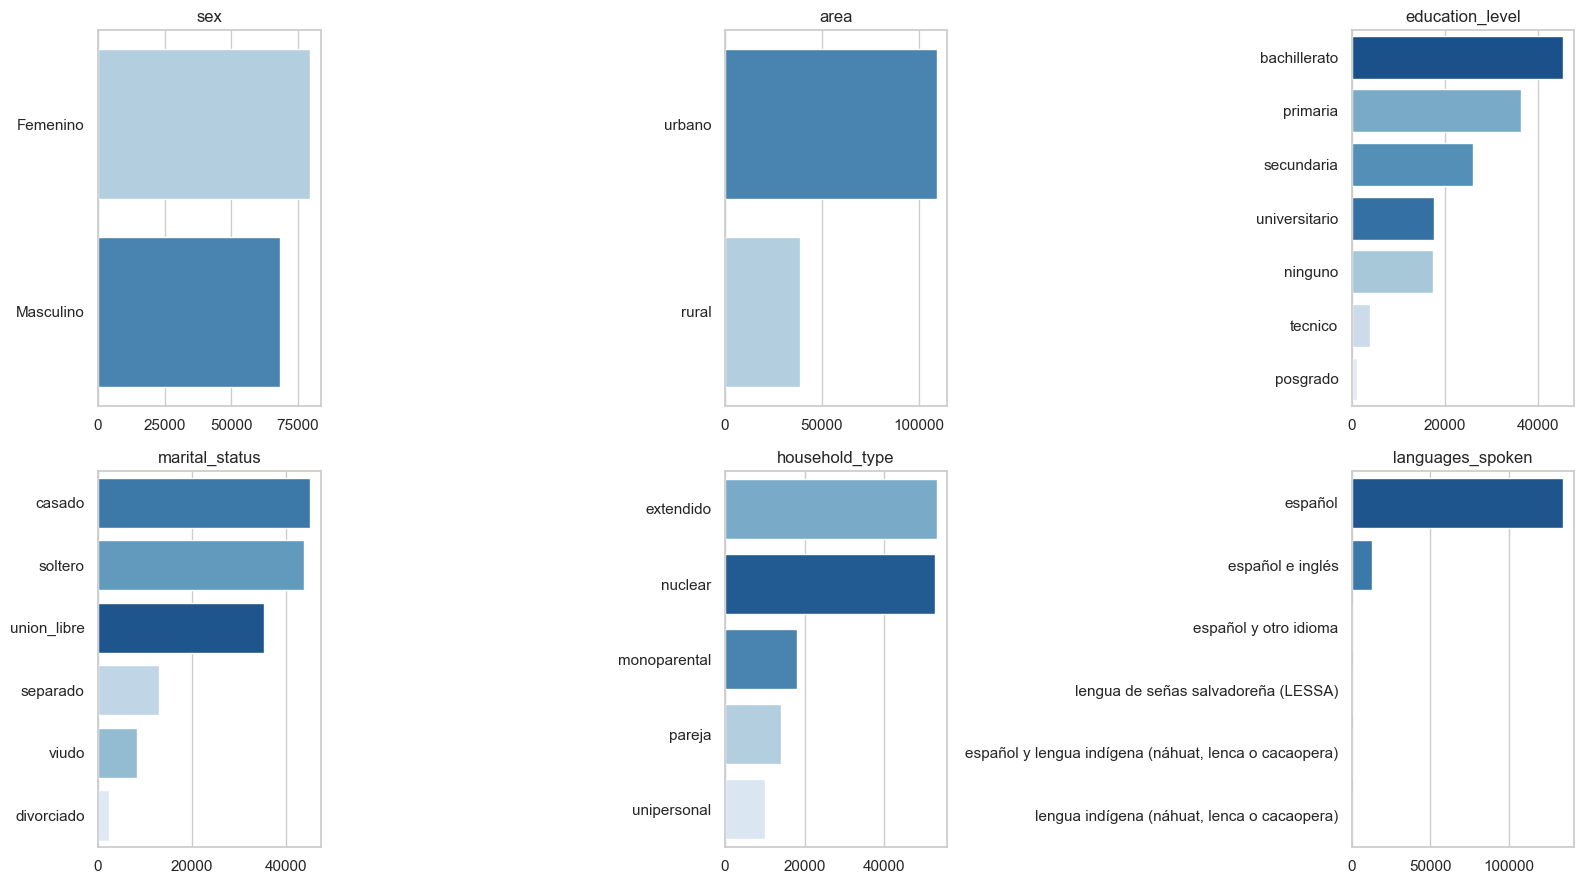

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, ["sex", "area", "education_level", "marital_status", "household_type", "languages_spoken"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, hue=col, legend=False, palette="Blues_r")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 5. Pirámide poblacional

Bins quinquenales de edad (igual que el dashboard), por sexo.

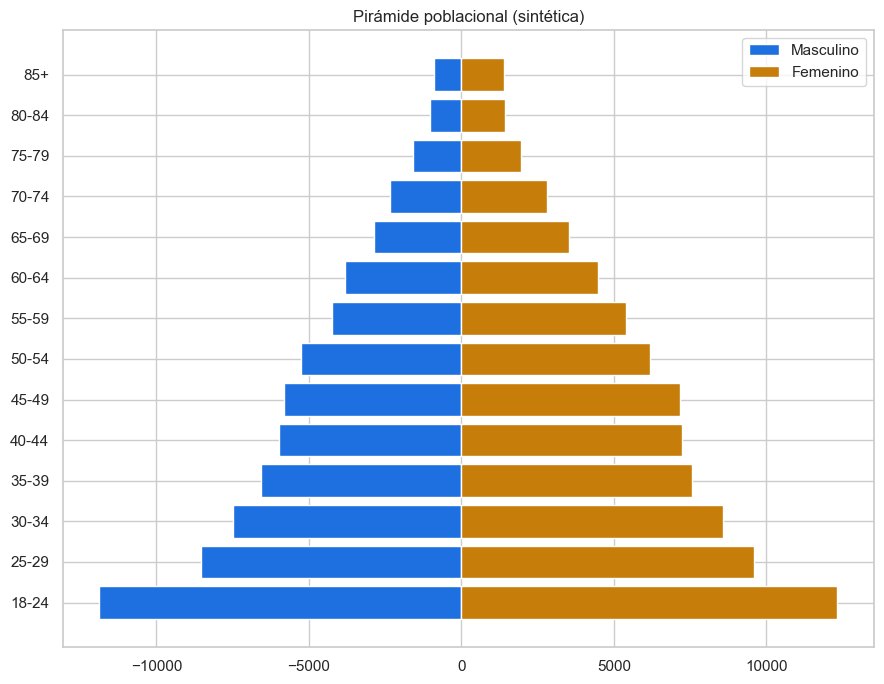

sex,Femenino,Masculino
age_bin,,
18-24,12316,11870
25-29,9607,8545
30-34,8587,7480
35-39,7567,6577
40-44,7240,5998
45-49,7160,5812
50-54,6188,5258
55-59,5395,4242
60-64,4461,3825


In [8]:
AGE_BINS = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59',
            '60-64','65-69','70-74','75-79','80-84','85+']

def age_bin(a):
    if a <= 24:
        return '18-24'
    if a >= 85:
        return '85+'
    lo = (a // 5) * 5
    return f'{lo}-{lo+4}'

df["age_bin"] = df["age"].apply(age_bin)
pyramid = (df.groupby(["age_bin", "sex"]).size().unstack(fill_value=0).reindex(AGE_BINS))

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(pyramid.index, -pyramid["Masculino"], color="#1e6fe0", label="Masculino")
ax.barh(pyramid.index, pyramid["Femenino"], color="#c77d0a", label="Femenino")
ax.set_title("Pirámide poblacional (sintética)")
ax.legend()
plt.tight_layout()
plt.show()
pyramid


## 6. Educación: crosstabs y brechas descriptivas

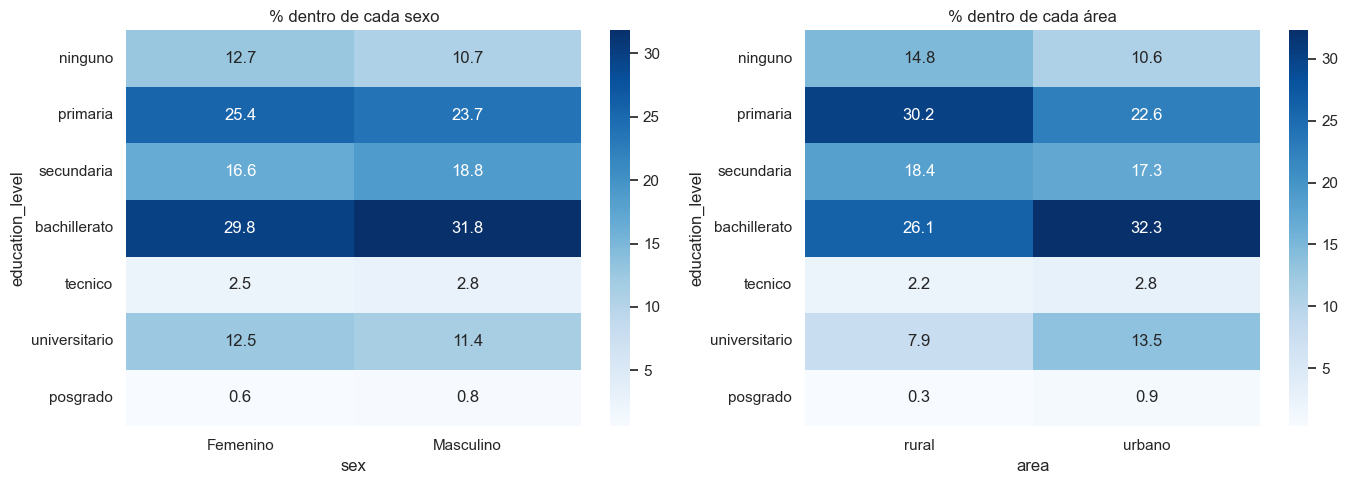

In [9]:
EDU_ORDER = ['ninguno', 'primaria', 'secundaria', 'bachillerato', 'tecnico', 'universitario', 'posgrado']
EDU_YEARS = {'ninguno': 0, 'primaria': 6, 'secundaria': 9, 'bachillerato': 12, 'tecnico': 14,
             'universitario': 16, 'posgrado': 18}
HIGHER = {'tecnico', 'universitario', 'posgrado'}

df["education_level"] = pd.Categorical(df["education_level"], categories=EDU_ORDER, ordered=True)
df["eduYears"] = df["education_level"].map(EDU_YEARS).astype(float)  # .astype: map() on Categorical keeps categorical dtype otherwise
df["higher"] = df["education_level"].isin(HIGHER)

ct_sex = pd.crosstab(df["education_level"], df["sex"], normalize="columns").round(3) * 100
ct_area = pd.crosstab(df["education_level"], df["area"], normalize="columns").round(3) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(ct_sex, annot=True, fmt=".1f", cmap="Blues", ax=axes[0])
axes[0].set_title("% dentro de cada sexo")
sns.heatmap(ct_area, annot=True, fmt=".1f", cmap="Blues", ax=axes[1])
axes[1].set_title("% dentro de cada área")
plt.tight_layout()
plt.show()


In [10]:
# brecha cruda de escolaridad (años) por sexo y por área
gap_gender_raw = df.loc[df.sex == "Femenino", "eduYears"].mean() - df.loc[df.sex == "Masculino", "eduYears"].mean()
gap_area_raw = df.loc[df.area == "urbano", "eduYears"].mean() - df.loc[df.area == "rural", "eduYears"].mean()
print(f"Brecha cruda escolaridad (F - M): {gap_gender_raw:+.3f} años")
print(f"Brecha cruda escolaridad (urbano - rural): {gap_area_raw:+.3f} años")
print("(la versión CONDICIONAL, controlando por edad/depto, se calcula en el notebook 02 con OLS)")


Brecha cruda escolaridad (F - M): -0.247 años
Brecha cruda escolaridad (urbano - rural): +1.255 años
(la versión CONDICIONAL, controlando por edad/depto, se calcula en el notebook 02 con OLS)


## 7. Estadística descriptiva de escolaridad por departamento

Media y desvío estándar de años de escolaridad (ponderados por la distribución de niveles
educativos), más los indicadores base del ICH.

In [11]:
dept_stats = df.groupby("department", observed=True).agg(
    count=("age", "size"),
    pctFemale=("sex", lambda s: round(100 * (s == "Femenino").mean(), 1)),
    pctUrban=("area", lambda s: round(100 * (s == "urbano").mean(), 1)),
    meanAge=("age", "mean"),
    eduYears=("eduYears", "mean"),
    eduStd=("eduYears", "std"),
    pctHigher=("higher", lambda s: round(100 * s.mean(), 1)),
).reset_index().sort_values("count", ascending=False)
dept_stats["eduYears"] = dept_stats["eduYears"].round(2)
dept_stats["eduStd"] = dept_stats["eduStd"].round(2)
dept_stats["meanAge"] = dept_stats["meanAge"].round(1)
dept_stats


,department,count,pctFemale,pctUrban,meanAge,eduYears,eduStd,pctHigher
9,San Salvador,39603,55.7,97.1,43.8,10.55,4.33,22.3
4,La Libertad,19625,53.9,82.2,42.8,9.79,4.66,19.9
11,Santa Ana,13868,54.1,72.9,43.3,8.91,4.63,14.9
12,Sonsonate,12111,52.9,75.8,41.7,8.51,4.42,10.0
8,San Miguel,11140,54.1,66.0,42.7,8.69,4.98,15.9
0,Ahuachapán,8728,53.0,69.2,41.7,8.10,4.53,8.6
13,Usulután,8094,53.4,54.5,43.0,8.17,4.69,10.1
5,La Paz,7737,52.8,65.9,41.7,8.69,4.25,9.1
3,Cuscatlán,6115,53.3,78.5,41.3,8.96,4.20,9.2
6,La Unión,5337,51.7,23.8,42.6,7.26,4.57,7.0


## 8. Índice de Capital Humano Sintético (ICH)

Mismo índice ilustrativo del dashboard: combinación min-max de **años de escolaridad (50%)**,
**% con educación superior (30%)** y **% urbano (20%)**, normalizado 0–100 entre departamentos.
No es un índice oficial — es un ejercicio de construcción de indicadores compuestos.

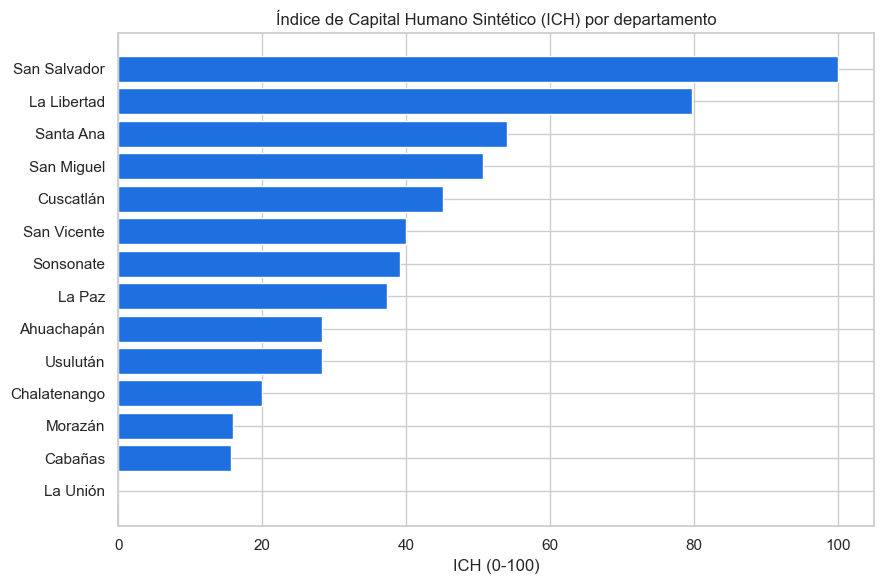

,department,eduYears,pctHigher,pctUrban,ich
9,San Salvador,10.55,22.3,97.1,100.0
4,La Libertad,9.79,19.9,82.2,79.7
11,Santa Ana,8.91,14.9,72.9,54.0
8,San Miguel,8.69,15.9,66.0,50.7
3,Cuscatlán,8.96,9.2,78.5,45.1
10,San Vicente,8.43,12.6,65.1,40.0
12,Sonsonate,8.51,10.0,75.8,39.1
5,La Paz,8.69,9.1,65.9,37.3
0,Ahuachapán,8.10,8.6,69.2,28.3
13,Usulután,8.17,10.1,54.5,28.3


In [12]:
def minmax(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else pd.Series(0.5, index=s.index)

dept_stats["ich"] = (
    100 * (0.5 * minmax(dept_stats["eduYears"])
           + 0.3 * minmax(dept_stats["pctHigher"])
           + 0.2 * minmax(dept_stats["pctUrban"]))
).round(1)

fig, ax = plt.subplots(figsize=(9, 6))
order = dept_stats.sort_values("ich", ascending=True)
ax.barh(order["department"], order["ich"], color="#1e6fe0")
ax.set_title("Índice de Capital Humano Sintético (ICH) por departamento")
ax.set_xlabel("ICH (0-100)")
plt.tight_layout()
plt.show()
dept_stats[["department", "eduYears", "pctHigher", "pctUrban", "ich"]].sort_values("ich", ascending=False)


## 9. Estructura ocupacional

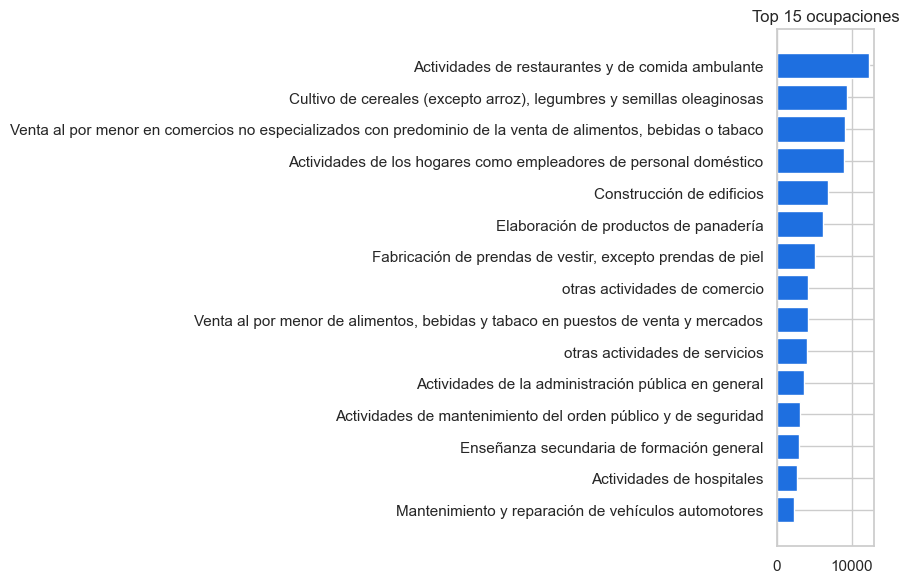

In [13]:
top_occ = df["occupation"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_occ.index[::-1], top_occ.values[::-1], color="#1e6fe0")
ax.set_title("Top 15 ocupaciones")
plt.tight_layout()
plt.show()


## 10. Habilidades y hobbies (NLP ligero)

Tokenización simple + frecuencia de palabras sobre las listas de habilidades/hobbies (JSON-encoded
strings), replicando `tokenize()` de `process.mjs`.

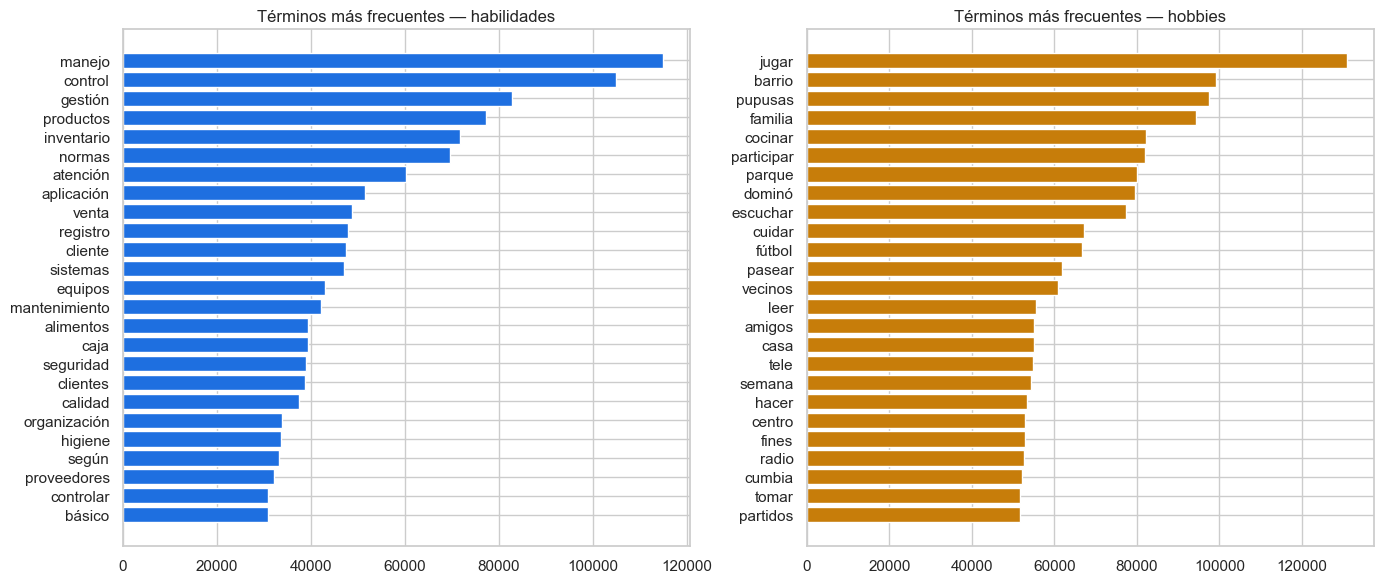

In [14]:
STOP = set(('de la el en y a los las del un una con por para su sus al lo se que como mas '
            'más o e u ni ademas además tambien también sobre entre desde hasta muy sin sus le '
            'les mi tu es son ser estar cada donde cuando quien cual todo toda todos todas otro '
            'otra este esta ese esa').split())

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-záéíóúñü\s]", " ", text)
    return [w for w in text.split() if len(w) > 3 and w not in STOP]

def parse_list(s):
    try:
        v = json.loads(s) if isinstance(s, str) else []
        return v if isinstance(v, list) else []
    except Exception:
        return []

def word_freq(series, n=25):
    from collections import Counter
    counter = Counter()
    for cell in series:
        for phrase in parse_list(cell):
            counter.update(tokenize(phrase))
    return pd.Series(dict(counter.most_common(n)))

skills_freq = word_freq(df["skills_and_expertise_list"])
hobbies_freq = word_freq(df["hobbies_and_interests_list"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(skills_freq.index[::-1], skills_freq.values[::-1], color="#1e6fe0")
axes[0].set_title("Términos más frecuentes — habilidades")
axes[1].barh(hobbies_freq.index[::-1], hobbies_freq.values[::-1], color="#c77d0a")
axes[1].set_title("Términos más frecuentes — hobbies")
plt.tight_layout()
plt.show()


## 11. Auditoría de sesgos por género

¿El LLM generador asocia ciertas ocupaciones/hobbies más a un sexo que otro, más allá de la
proporción base de género del dataset? Comparamos el % femenino de cada categoría contra el
baseline global (filtrando categorías con n suficiente para ser informativas).

In [15]:
baseline_female = round(100 * (df["sex"] == "Femenino").mean(), 1)
print(f"% femenino baseline del dataset: {baseline_female}%")

occ_gender = (df.groupby("occupation")["sex"]
              .value_counts(normalize=True).unstack(fill_value=0) * 100).round(1)
occ_gender["n"] = df["occupation"].value_counts()
occ_gender = occ_gender[occ_gender["n"] >= 400]

print("\nOcupaciones con MAYOR % femenino (vs. baseline):")
print(occ_gender.sort_values("Femenino", ascending=False).head(8)[["Femenino", "n"]])
print("\nOcupaciones con MENOR % femenino (más masculinizadas):")
print(occ_gender.sort_values("Femenino", ascending=True).head(8)[["Femenino", "n"]])


% femenino baseline del dataset: 53.8%

Ocupaciones con MAYOR % femenino (vs. baseline):
sex                                                 Femenino      n
occupation                                                         
Lavado y limpieza, incluida la limpieza en seco...      97.8    406
Venta al por menor por correo y por Internet            94.3    941
Actividades de los hogares como empleadores de ...      91.5   8996
Actividades de restaurantes y de comida ambulante       85.1  12359
Otras actividades de atención de la salud humana        81.7   1408
Peluquería y otros tratamientos de belleza              81.5   1788
Venta al por menor en comercios no especializad...      80.4   9163
Venta al por menor de prendas de vestir, calzad...      80.3    518

Ocupaciones con MENOR % femenino (más masculinizadas):
sex                                                 Femenino     n
occupation                                                        
Otras actividades de transporte por vía t

## Conclusiones y límites

- La estadística descriptiva y los índices construidos aquí (ICH, distribuciones, sesgos) son
  **coherentes con el pipeline de Node.js del repo** (`src/process.mjs`) — mismos resultados,
  otro lenguaje.
- **Todo es sobre datos sintéticos.** No usar como fuente de estadística oficial de El Salvador.
- El notebook `02_modelos_econometricos_espaciales_nlp.ipynb` retoma estos datos para los modelos
  (OLS, logit ordenado/multinomial, autocorrelación espacial, supervivencia, NLP distintivo).

**Repo:** https://github.com/MirandaCR/el-salvador-sintetico ·
**Dashboard:** https://mirandacr.github.io/el-salvador-sintetico/ ·
**Licencia:** CC-BY-4.0 — atribución a Cristian Miranda.
